__MLP Model For Water Quality Prediction from a Feature Vector (3 Classes)__

Code to load in the merged_metadata Excel file and filter for relevent metadata columns that could be used to predict water quality (0-poor, 1-moderate, 2-good).

Initially, an MLP (Mylti-Layer Perceptron) is trained and evaluated using a feature vector. 

An XGBoost (Extreme Gradient Boosting) model is also trained and evaluated for a comparison. However, the MLP is expected to perform better as MLPs typically perform better with complex feature learning whilst EGBoost is better with structured data, and its performance depends heavily on the dataset.

These models both use all 3 original classes of water quality as targets.
 

Note-the XGBoost model is in progress still

In [1]:
#Import modules

#Basic
import numpy as np
from pathlib import Path
import pandas as pd
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

#Scikit-learn
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#For the models
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

#Explainability
import shap


2026-01-14 09:29:51.806636: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-14 09:29:51.862280: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-14 09:29:52.905358: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/tqdm/auto.py:21: 

In [2]:
#Loading the csv
#Setting the path
REPO_NAME = "earthwatch-cnn"
BASE_DIR = next(
    p for p in Path.cwd().parents
    if p.name == REPO_NAME)
DATA_DIR = BASE_DIR / "data"

#Loading the data
merged_df = pd.read_excel(DATA_DIR / "merged_metadata.xlsx")


In [3]:
#Displaying the merged dataframe
merged_df

,downloaded_utc,layer_title,layer_id,feature_object_id,feature_global_id,geometry_x,geometry_y,attachment_id,attachment_global_id,attachment_name,...,feedback_score,County,RBD_NAME,MNCAT_NAME,Nitrate (mg/L) MID,Phosphate (mg/L) MID,Photo URL,x,y,image_path
0,2025-11-26T17:48:11Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,12,f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a,-4.011572,52.434782,6,120e143f-b55e-4c10-aced-8b8f36ab4561,photo-20240525-180858.jpg,...,1,Dyfed,Western Wales,Teifi and North Ceredigion,0.75,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-4.011572,52.434782,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
1,2025-11-26T17:48:17Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,13,3ba0caef-1459-47ca-bcff-bb6a8b253ca4,-1.997459,53.932339,7,01b85181-5e16-4bce-8ec1-864890e0eee6,photo-20240526-115416.jpg,...,2,North Yorkshire,Humber,Aire and Calder,1.50,0.075,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.997459,53.932339,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
2,2025-11-26T17:48:23Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,15,9ab3ef19-b92e-495d-8330-e5cab4f52139,-0.490153,51.398517,8,93b0b358-2840-496f-9c50-beb08e550091,photo-20240531-072047.jpg,...,3,Surrey,Thames,Maidenhead and Sunbury,7.50,0.150,https://services3.arcgis.com/SQtySBftABENTpkx/...,-0.490153,51.398517,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
3,2025-11-26T17:48:29Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,16,7065d44e-868d-41a8-bc29-3e380d44a284,-1.705773,53.341469,9,967fdeb6-6016-43ed-954a-e2778dd0fe31,photo-20240531-184342.jpg,...,1,Derbyshire,Humber,Derwent Derbyshire,0.75,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.705773,53.341469,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
4,2025-11-26T17:48:35Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,17,ece94aea-b3a2-4c72-a1b0-66b329185eb8,-1.633728,53.797123,10,e895f878-0577-40ae-9a49-ecd991ffcf85,photo-20240601-110123.jpg,...,3,West Yorkshire,Humber,Aire and Calder,3.50,0.035,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.633728,53.797123,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8999,2025-11-27T14:03:26Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11545,7479327a-dda2-4647-8e19-176fc7b7c208,-1.776789,53.921762,9974,a538e4f9-dda1-437e-8f73-952f969aa748,IMG_20251108_151702379_HDR.jpg,...,3,West Yorkshire,Humber,Wharfe and Ouse Lower,10.00,1.000,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.776789,53.921762,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9000,2025-11-27T14:03:36Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11546,9ca17c49-6a38-405f-8369-caebcbb4c445,-1.682858,53.910390,9975,d6c0b93c-614f-40f8-8129-362d9b85f4b7,IMG_20251112_123816085_HDR.jpg,...,1,West Yorkshire,Humber,Wharfe and Ouse Lower,0.35,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.682858,53.910390,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9001,2025-11-27T14:03:47Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11547,f077fd29-55c0-484c-8b03-aa1d54844b54,-1.659827,53.913112,9976,1869abcf-7f8f-4a66-86ea-c1a2b0faaef3,IMG_20251112_130858731_HDR.jpg,...,1,North Yorkshire,Humber,Wharfe and Ouse Lower,0.35,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.659827,53.913112,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9002,2025-11-27T14:03:57Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11548,8279d341-cfc1-4852-8b19-a58dc6eee304,-1.625267,53.904750,9977,4af7180e-6b14-4fce-8190-948063dbb8d2,IMG_20251122_091305231_HDR.jpg,...,2,North Yorkshire,Humber,Wharfe and Ouse Lower,1.50,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.625267,53.904750,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...


In [4]:
#Selecting only the columns we want
#Not selecting any empty columns

filtered_df=merged_df[["feature_global_id", "feedback_score","Freshwater body type","What is the main land use within 50m?","You selected other, what is the main land use?", 
                       "What is the main bank vegetation? (select all that apply)","You selected other, what is the main bank vegetation?","Vegetation cover in/on the water (%)",
                       "Is there any of the following on the water surface?", "Estimate the water colour","You selected other, enter the colour"]]

#Displaying the filtered dataframe
filtered_df
#feedback score - 1-poor, 3-good -changes to 0...2

,feature_global_id,feedback_score,Freshwater body type,What is the main land use within 50m?,"You selected other, what is the main land use?",What is the main bank vegetation? (select all that apply),"You selected other, what is the main bank vegetation?",Vegetation cover in/on the water (%),Is there any of the following on the water surface?,Estimate the water colour,"You selected other, enter the colour"
0,f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a,1,River,Forest,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
1,3ba0caef-1459-47ca-bcff-bb6a8b253ca4,2,Stream,Rural_residential,NaN,"Grass_small_plants,Trees_shrubs",NaN,NaN,NaN,Colourless,NaN
2,9ab3ef19-b92e-495d-8330-e5cab4f52139,3,River,Urban_green_space,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
3,7065d44e-868d-41a8-bc29-3e380d44a284,1,River,Livestock,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
4,ece94aea-b3a2-4c72-a1b0-66b329185eb8,3,River,Urban_green_space,NaN,"Trees_shrubs,Grass_small_plants,Concrete_imper...",NaN,NaN,NaN,Colourless,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8999,7479327a-dda2-4647-8e19-176fc7b7c208,3,River,Grassland_shrub,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
9000,9ca17c49-6a38-405f-8369-caebcbb4c445,1,River,Urban_green_space,NaN,"Trees_shrubs,Grass_small_plants,Bare_soil",NaN,NaN,Foam,Brown,NaN
9001,f077fd29-55c0-484c-8b03-aa1d54844b54,1,River,Arable_agricultural,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
9002,8279d341-cfc1-4852-8b19-a58dc6eee304,2,River,Livestock,NaN,"Trees_shrubs,Grass_small_plants,Bare_soil",NaN,NaN,NaN,Colourless,NaN


In [10]:
#Dataframe pre-processing for ML training 
#Need to change the data from categories to numerical values and normalise. 

#Splitting the columns into different data types. 
multilabel_col = "What is the main bank vegetation? (select all that apply)"
nominal_cols = [
    "Freshwater body type",
    "What is the main land use within 50m?",
    "Is there any of the following on the water surface?",
    "Estimate the water colour"
]
numeric_cols = ["Vegetation cover in/on the water (%)"]
TARGET = "feedback_score"

filtered_df = filtered_df.copy()

def normalize_multilabel(x):
    #Explicit handling for list/array-like types (do this first)
    if isinstance(x, (list, tuple, set, np.ndarray)):
        #Convert to plain python list of stripped strings
        out = []
        for v in x:
            if v is None:
                continue
            s = str(v).strip()
            if s and s.lower() not in ("nan", "none"):
                out.append(s)
        return out

    #Now use pd.isna
    if pd.isna(x):
        return []

    #Split strings/other scalars on the comma
    s = str(x).strip()
    if s == "" or s.lower() in ("nan", "none"):
        return []
    parts = [p.strip() for p in s.split(",") if p.strip()]
    return parts

#Apply normalization
filtered_df.loc[:, multilabel_col] = filtered_df[multilabel_col].apply(normalize_multilabel)

#Build the bank_veg_df using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
bank_veg_encoded = mlb.fit_transform(filtered_df[multilabel_col])
bank_veg_df = pd.DataFrame(
    bank_veg_encoded,
    index=filtered_df.index,
    columns=[f"bankveg_{c}" for c in mlb.classes_]
)
bankveg_feature_names = [f"bankveg_{c}" for c in mlb.classes_]
print("bank_veg_df.shape:", bank_veg_df.shape)
print("bankveg classes (sample):", mlb.classes_[:20])

#Ensure nominal columns are strings
def to_str_val(v):
    if isinstance(v, (list, tuple, set, np.ndarray)):
        return "|".join([str(x).strip() for x in v if x is not None and str(x).strip().lower() not in ("nan","none")])
    if pd.isna(v):
        return ""
    return str(v).strip()

for c in nominal_cols:
    filtered_df.loc[:, c] = filtered_df[c].apply(to_str_val)

#Numeric fill
filtered_df.loc[:, numeric_cols] = filtered_df[numeric_cols].astype(float).fillna(0.0)

#ColumnTransformer (exclude multi-label col)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("num", StandardScaler(), numeric_cols),
    ],
    remainder="drop"
)

X_base_arr = preprocessor.fit_transform(filtered_df)

#Check if X_base_arr is sparse and make dense
try:
    from scipy import sparse
    if sparse.issparse(X_base_arr):
        X_base_arr = X_base_arr.toarray()
except Exception:
    pass

#Set column names
try:
    cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(nominal_cols)
    base_cols = list(numeric_cols) + list(cat_names)
except Exception:
    base_cols = [f"base_{i}" for i in range(X_base_arr.shape[1])]

X_base_df = pd.DataFrame(X_base_arr, index=filtered_df.index, columns=base_cols[:X_base_arr.shape[1]])
bank_veg_df = bank_veg_df.reindex(filtered_df.index).fillna(0).astype(int)
X_df = pd.concat([X_base_df, bank_veg_df], axis=1)
X = X_df.values
y = filtered_df[TARGET].astype(int).values - 1
feature_names = base_cols + bankveg_feature_names

#Check shapes
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)


bank_veg_df.shape: (9004, 5)
bankveg classes (sample): ['Bare_soil' 'Concrete_impermeable_surface' 'Grass_small_plants' 'Other'
 'Trees_shrubs']
Final X shape: (9004, 64)
Final y shape: (9004,)


In [6]:
#Checking the shapes of X and y and the new target classes, now 0..2 instead of 1..3
print("X shape:", X.shape)   # (n_samples, n_features)
print("y shape:", y.shape)   # (n_samples,)
print("y classes:", np.unique(y))

X shape: (9004, 64)
y shape: (9004,)
y classes: [0 1 2]


In [7]:
#Divide the data into training, validation and testing. 

#Split test off from training+validation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)

#Split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp)
#Final 80/10/10 split

print(X_train.shape, X_val.shape, X_test.shape)


(7202, 64) (901, 64) (901, 64)


In [ ]:
#MPL model
#Training

#Setting parameters and loading training data
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

#Cap extreme weights
for k in class_weight:
    class_weight[k] = min(class_weight[k], 3.0)

#Building the model using keras with dropout
model = tf.keras.Sequential([
    layers.Input(shape=(X.shape[1],)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])



#Setting Adam as the optimiser
opt = tf.keras.optimizers.Adam(learning_rate=1e-4)   # try 1e-4 or 5e-5
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Early stopping to prevent overfitting
es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

#Storing the model history
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[es,rlr]
)

#Evaluating the model on the test set
y_test_cat = to_categorical(y_test, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy:", test_acc)

#Detailed classification metrics on validation set
y_val_proba = model.predict(X_val)
y_val_pred = np.argmax(y_val_proba, axis=1)
y_val_true = np.argmax(y_val_cat, axis=1)

#Compute metrics
print("\nValidation accuracy:", accuracy_score(y_val_true, y_val_pred))
print("\nClassification report (val):")
print(classification_report(y_val_true, y_val_pred, digits=4))

print("\nConfusion matrix (val):")
print(confusion_matrix(y_val_true, y_val_pred))


2026-01-14 09:34:31.585538: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3441 - loss: 1.1639 - val_accuracy: 0.4584 - val_loss: 1.1477 - learning_rate: 1.0000e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3785 - loss: 1.1526 - val_accuracy: 0.4218 - val_loss: 1.1407 - learning_rate: 1.0000e-04
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4025 - loss: 1.1458 - val_accuracy: 0.4495 - val_loss: 1.1316 - learning_rate: 1.0000e-04
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4189 - loss: 1.1360 - val_accuracy: 0.4440 - val_loss: 1.1192 - learning_rate: 1.0000e-04
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4418 - loss: 1.1279 - val_accuracy: 0.4417 - val_loss: 1.1237 - learning_rate: 1.0000e-04
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4304 - loss: 1.1256 - val_accuracy: 0.4506 - val_loss: 1.1141 - learning_rate: 1.0000e-04
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 

With no weights:
The model is learning real signals but its performance is uneven across classes: Class 1 (moderate) is effectively not being learned
The overall accuracy (~0.50) is meaningful but misleading on its own.
Class 0: precision: 0.51, recall: 0.43, F1: 0.46, Support 326 - Moderarely learned, but confused with class 2?\
Class 1: precision and recall and F1: 0.00, support: 187. Class 1 is never predicted correctly. \
Class 2: precision: 0.49, recall: 0.79, F1: 0.61, Support: 388. Best learned class. 

With class-weighting: The validation accuracy dropped because the model stopped over-predicting class 2. However the class 1 recall and the macro F1 increased. (F1 is an unweighted average of the F1 scores for each individual class)


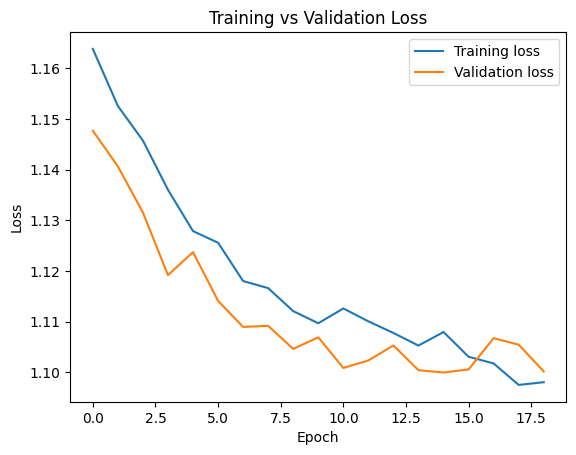

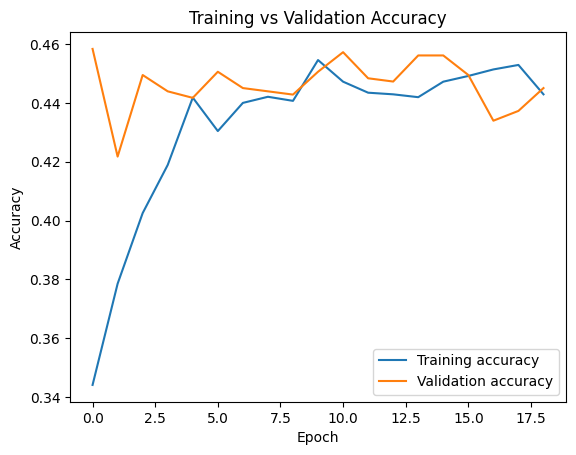

In [9]:
#Inspection of training process
#Loss curve
plt.figure()
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

#Accuracy curve
plt.figure()
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


In [16]:
#SHAP PLOTS FOR EACH CLASS HERE
#SETTINGS
n_background = 200          # number of background samples for explainer (tradeoff speed/accuracy)
n_viz_samples = 500         # number of validation samples to compute SHAP on (for plotting)
top_k_features = 30         # how many top features to show in bar plots
random_state = 42
# -------------------------------

np.random.seed(random_state)

# Ensure arrays
X_train_arr = np.asarray(X_train)
X_val_arr   = np.asarray(X_val)

# Create feature names if none provided
if 'feature_names' in globals() and len(feature_names) == X_train_arr.shape[1]:
    feat_names = list(feature_names)
else:
    feat_names = [f"f{i}" for i in range(X_train_arr.shape[1])]

# Pick background and eval subsets (avoid using huge sets for KernelExplainer)
bg_idx = np.random.choice(np.arange(len(X_train_arr)), size=min(n_background, len(X_train_arr)), replace=False)
background = X_train_arr[bg_idx]

val_idx = np.random.choice(np.arange(len(X_val_arr)), size=min(n_viz_samples, len(X_val_arr)), replace=False)
X_val_small = X_val_arr[val_idx]

# Try GradientExplainer / DeepExplainer first (fast for NN), fallback to KernelExplainer if it errors.
explainer = None
shap_values = None

print("Trying GradientExplainer (fast) ...")
try:
    # For TF2 Keras models, GradientExplainer often works well for softmax outputs
    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(X_val_small)
    print("GradientExplainer OK.")
except Exception as e:
    print(f"GradientExplainer failed: {e}\nTrying DeepExplainer ...")
    try:
        explainer = shap.DeepExplainer(model, background)
        shap_values = explainer.shap_values(X_val_small)
        print("DeepExplainer OK.")
    except Exception as e2:
        print(f"DeepExplainer failed: {e2}\nFalling back to KernelExplainer (slow)...")
        # Kernel explainer expects a function returning model outputs (probabilities)
        def f(X):
            X = np.asarray(X, dtype=np.float32)
            return model.predict(X)
        explainer = shap.KernelExplainer(f, background[:min(100, len(background))])
        shap_values = explainer.shap_values(X_val_small, nsamples=200)  # increase nsamples for accuracy
        print("KernelExplainer done (this can be slow).")

# shap_values: for multiclass this will be a list with one array per class of shape (n_samples, n_features)
# If explainer returned a single array (sometimes shap returns array for binary), normalize into list
if not isinstance(shap_values, list):
    shap_values = [shap_values]

num_classes = len(shap_values)
class_labels = classes if 'classes' in globals() else np.arange(num_classes)

# Create output folder for plots
import os
out_dir = "shap_plots_per_class"
os.makedirs(out_dir, exist_ok=True)
n_samples = X_val_small.shape[0]
n_features = X_val_small.shape[1]
num_classes = len(class_labels)

# Ensure variable exists
if 'shap_values' not in globals():
    raise RuntimeError("shap_values not found. Compute explainer.shap_values(...) first.")

# Helper to split a 3D array into list of (n_samples, n_features) arrays
def split_3d_array(arr3d):
    arr = np.asarray(arr3d)
    if arr.shape == (n_samples, n_features, num_classes):
        # (n_samples, n_features, n_classes) -> transpose to (n_classes, n_samples, n_features)
        arr2 = arr.transpose(2, 0, 1)
        return [arr2[c] for c in range(num_classes)]
    if arr.shape == (n_samples, num_classes, n_features):
        # (n_samples, n_classes, n_features) -> split over axis=1
        return [arr[:, c, :] for c in range(num_classes)]
    if arr.shape == (num_classes, n_samples, n_features):
        # already (n_classes, n_samples, n_features)
        return [arr[c] for c in range(num_classes)]
    # other shapes: try some reasonable transposes
    # (num_features, n_samples, num_classes) -> transpose to (num_classes, n_samples, num_features)
    if arr.shape[0] == n_features and arr.shape[1] == n_samples and arr.shape[2] == num_classes:
        arr2 = arr.transpose(2, 1, 0)
        return [arr2[c] for c in range(num_classes)]
    # fallback: not supported
    raise ValueError(f"Unhandled 3D shap array shape: {arr.shape}")

shap_per_class = None

# Case A: shap_values is a list
if isinstance(shap_values, list):
    # If list of length == num_classes and each element is 2D of shape (n_samples, n_features) => done
    if len(shap_values) == num_classes and all(np.asarray(a).ndim == 2 for a in shap_values):
        shap_per_class = [np.asarray(a) for a in shap_values]
    # If list length == 1 and element is 3D (common) => split it
    elif len(shap_values) == 1:
        arr0 = np.asarray(shap_values[0])
        if arr0.ndim == 2:
            # single 2D array but multi-class expected -> ambiguous
            if num_classes == 1:
                shap_per_class = [arr0]
            else:
                raise ValueError(f"Received single 2D shap array but expected {num_classes} classes. Shape: {arr0.shape}")
        elif arr0.ndim == 3:
            shap_per_class = split_3d_array(arr0)
        else:
            raise ValueError(f"Unhandled ndim for shap_values[0]: {arr0.ndim}, shape {arr0.shape}")
    else:
        # Some libraries may return weird lists (e.g., one array per model output including extra dims)
        # Try to coerce each element: if any element is 3D we attempt to split it and gather.
        temp = []
        for idx, el in enumerate(shap_values):
            a = np.asarray(el)
            if a.ndim == 2:
                temp.append(a)
            elif a.ndim == 3:
                # try splitting; if returns list, extend
                split = split_3d_array(a)
                temp.extend(split)
            else:
                raise ValueError(f"Unhandled shape for shap_values list element {idx}: {a.shape}")
        # If we ended up with exactly num_classes 2D arrays, adopt them
        if len(temp) == num_classes and all(t.ndim == 2 for t in temp):
            shap_per_class = temp
        else:
            raise ValueError(f"After coercion, got {len(temp)} arrays but expected {num_classes}")
# Case B: shap_values is a single ndarray (not a list)
else:
    arr = np.asarray(shap_values)
    if arr.ndim == 2:
        if num_classes == 1:
            shap_per_class = [arr]
        else:
            raise ValueError(f"Received 2D shap_values but expected {num_classes} classes. Shape: {arr.shape}")
    elif arr.ndim == 3:
        shap_per_class = split_3d_array(arr)
    else:
        raise ValueError(f"Unhandled shap_values ndim: {arr.ndim}, shape: {arr.shape}")

# Final sanity checks
shap_per_class = [np.asarray(a) for a in shap_per_class]
for i, a in enumerate(shap_per_class):
    if a.shape != (n_samples, n_features):
        raise ValueError(f"Class {i} shap shape mismatch: got {a.shape}, expected {(n_samples, n_features)}")

print("Normalized shap_per_class shapes:", [a.shape for a in shap_per_class])

# For each class: summary (beeswarm) + bar chart of mean(|shap|)
for c in range(num_classes):
    class_name = str(class_labels[c])
    print(f"\nPlotting class {c} (label: {class_name})")

    # SUMMARY / BEESWARM plot
    plt.figure(figsize=(12, 8))
    # shap.summary_plot expects shap_values for the class (n_samples, n_features)
    # but in older versions shap.summary_plot returns inline; to avoid it using IPython display, call like below:
    shap.summary_plot(shap_per_class[c], X_val_small, feature_names=feat_names, show=False)
    plt.gcf().subplots_adjust(left=0.5)  #(adjust if needed)
    plt.title(f"SHAP summary (beeswarm) for class {class_name}")
    plt.tight_layout()
    filename1 = os.path.join(out_dir, f"shap_beeswarm_class_{class_name}.png")
    plt.savefig(filename1, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {filename1}")

    # BAR chart of mean absolute SHAP values
    # ensure shap_values[c] is a 2D numpy array
    sh_vals_c = np.asarray(shap_per_class[c])
    if sh_vals_c.ndim != 2:
        raise ValueError(f"Expected shap_values for class {c} to be 2D (n_samples, n_features), got shape {sh_vals_c.shape}")

    # mean absolute shap per feature (1D)
    mean_abs_shap = np.mean(np.abs(sh_vals_c), axis=0).ravel()

    # Defensive checks
    feat_names_arr = np.asarray(feat_names)   # convert to ndarray so we can index with arrays
    n_features = mean_abs_shap.shape[0]
    if feat_names_arr.shape[0] != n_features:
        raise ValueError(f"Feature-name count ({feat_names_arr.shape[0]}) != number of shap features ({n_features})")

    # argsort -> descending
    idx_sorted = np.argsort(mean_abs_shap)[::-1]

    # clamp top_k_features to available features
    k = min(top_k_features, n_features)
    top_idx = idx_sorted[:k].astype(int)   # ensure integer dtype

    # now safely index feature names (numpy supports array indexing)
    top_feats = feat_names_arr[top_idx].tolist()
    top_vals = mean_abs_shap[top_idx]

    # Plot horizontal bar (keeps previous style)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    y_pos = np.arange(len(top_feats))[::-1]  # reverse for horizontal bar
    plt.barh(y_pos, top_vals[::-1])
    plt.yticks(y_pos, top_feats[::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"Top {len(top_feats)} features by mean |SHAP| for class {class_name}")
    plt.tight_layout()

    filename2 = os.path.join(out_dir, f"shap_meanabs_bar_class_{class_name}.png")
    plt.savefig(filename2, dpi=150)
    plt.close()
    print(f"Saved: {filename2}")

    plt.figure(figsize=(10, 6))
    y_pos = np.arange(len(top_feats))[::-1]  # reverse for horizontal bar
    plt.barh(y_pos, top_vals[::-1])
    plt.yticks(y_pos, top_feats[::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"Top {len(top_feats)} features by mean |SHAP| for class {class_name}")
    plt.tight_layout()
    filename2 = os.path.join(out_dir, f"shap_meanabs_bar_class_{class_name}.png")
    plt.savefig(filename2, dpi=150)
    plt.close()
    print(f"Saved: {filename2}")

    # Optional: force plot for a few representative samples (e.g., median magnitude sample)
    # Choose a sample whose sum(|shap|) is near the median to show a "typical" explanation
    sample_mags = np.sum(np.abs(shap_per_class[c]), axis=1)
    median_idx = np.argsort(np.abs(sample_mags - np.median(sample_mags)))[0]
    sample_idx_global = val_idx[median_idx]  # original index in X_val

    # force_plot (html) — create and save as PNG using matplotlib wrapper
    # Note: shap.force_plot returns a JS/HTML object. We'll render a matplotlib fallback plot of top contributions.
    # Build top contributing features for that sample:
    sample_shap = shap_per_class[c][median_idx]
    topk = min(15, X_val_small.shape[1])
    topk_idx = np.argsort(np.abs(sample_shap))[::-1][:topk]
    contrib_feats = [feat_names[i] for i in topk_idx]
    contrib_vals = sample_shap[topk_idx]
    contrib_base = explainer.expected_value[c] if (hasattr(explainer, "expected_value") and isinstance(explainer.expected_value, (list, np.ndarray))) else None

    plt.figure(figsize=(10, 5))
    colors = ['green' if v>0 else 'red' for v in contrib_vals]
    plt.barh(np.arange(len(contrib_feats))[::-1], contrib_vals[::-1], color=colors[::-1])
    plt.yticks(np.arange(len(contrib_feats))[::-1], contrib_feats[::-1])
    plt.xlabel("SHAP value (positive -> supports prediction for this class)")
    title = f"Top {topk} feature contributions (sample idx in X_val: {sample_idx_global}) for class {class_name}"
    if contrib_base is not None:
        title += f"\n(expected value for class: {float(np.round(contrib_base,4))})"
    plt.title(title)
    plt.tight_layout()
    filename3 = os.path.join(out_dir, f"shap_topcontrib_sample_class_{class_name}.png")
    plt.savefig(filename3, dpi=150)
    plt.close()
    print(f"Saved: {filename3}")

print("\nAll plots saved to folder:", out_dir)
print("Examples:")
print(" - beeswarm summary: shap_beeswarm_class_<label>.png")
print(" - mean |SHAP| bar: shap_meanabs_bar_class_<label>.png")
print(" - example per-sample contributions: shap_topcontrib_sample_class_<label>.png")



Trying GradientExplainer (fast) ...


/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(500, 64))']
  warnings.warn(msg)
/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 64))']
  warnings.warn(msg)


GradientExplainer OK.
Normalized shap_per_class shapes: [(500, 64), (500, 64), (500, 64)]

Plotting class 0 (label: 0)


/tmp/ipykernel_1445/296339107.py:164: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_class[c], X_val_small, feature_names=feat_names, show=False)
/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_1445/296339107.py:167: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved: shap_plots_per_class/shap_beeswarm_class_0.png
Saved: shap_plots_per_class/shap_meanabs_bar_class_0.png
Saved: shap_plots_per_class/shap_meanabs_bar_class_0.png
Saved: shap_plots_per_class/shap_topcontrib_sample_class_0.png

Plotting class 1 (label: 1)


/tmp/ipykernel_1445/296339107.py:164: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_class[c], X_val_small, feature_names=feat_names, show=False)
/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_1445/296339107.py:167: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved: shap_plots_per_class/shap_beeswarm_class_1.png
Saved: shap_plots_per_class/shap_meanabs_bar_class_1.png
Saved: shap_plots_per_class/shap_meanabs_bar_class_1.png
Saved: shap_plots_per_class/shap_topcontrib_sample_class_1.png

Plotting class 2 (label: 2)


/tmp/ipykernel_1445/296339107.py:164: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_class[c], X_val_small, feature_names=feat_names, show=False)
/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_1445/296339107.py:167: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved: shap_plots_per_class/shap_beeswarm_class_2.png
Saved: shap_plots_per_class/shap_meanabs_bar_class_2.png
Saved: shap_plots_per_class/shap_meanabs_bar_class_2.png
Saved: shap_plots_per_class/shap_topcontrib_sample_class_2.png

All plots saved to folder: shap_plots_per_class
Examples:
 - beeswarm summary: shap_beeswarm_class_<label>.png
 - mean |SHAP| bar: shap_meanabs_bar_class_<label>.png
 - example per-sample contributions: shap_topcontrib_sample_class_<label>.png


In [64]:
#XGBOOST model

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train, y_train)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


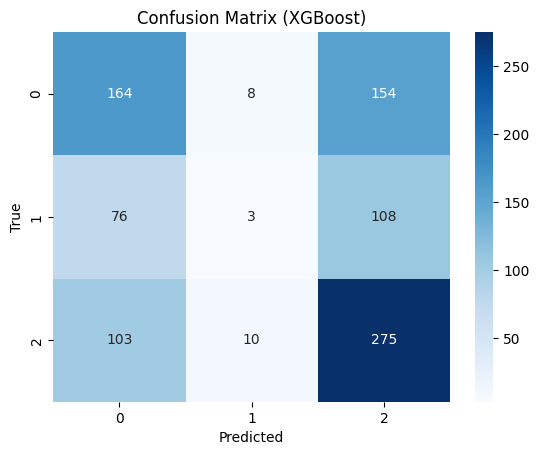

In [ ]:
#Plotting confusion matrix
#Predict class labels
y_val_pred = xgb.predict(X_val)
#Probabilities
y_val_proba = xgb.predict_proba(X_val)
if y_val_pred.ndim == 2 and y_val_pred.shape[1] > 1:
    y_val_pred_labels = np.argmax(y_val_pred, axis=1)
else:
    y_val_pred_labels = y_val_pred  # leave as-is, will be checked below   

cm = confusion_matrix(y_val, y_val_pred_labels)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (XGBoost)")
plt.show()


In [71]:
# majority-class baseline
majority_acc = (y_val == np.bincount(y_train).argmax()).mean()
print("Majority class baseline accuracy:", majority_acc)

Majority class baseline accuracy: 0.4306326304106548


In [72]:
#Finding out which features are most important in the classification
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=X_df.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(20))


Freshwater body type_Ditch                                                   0.045428
What is the main land use within 50m?_Arable_agricultural                    0.038120
What is the main land use within 50m?_Industrial_commercial                  0.037766
Freshwater body type_Other                                                   0.032134
Estimate the water colour_Colourless                                         0.029500
What is the main land use within 50m?_                                       0.028819
Is there any of the following on the water surface?_Floating_algae,Slurry    0.028712
Estimate the water colour_Green                                              0.023906
Is there any of the following on the water surface?_Oily_sheen               0.023282
What is the main land use within 50m?_Urban_green_space                      0.022149
Freshwater body type_River                                                   0.022086
What is the main land use within 50m?_Livestock       